# DS201 Final Project — Tips Dataset

**Course:** DS201 — Data Exploration & Visualization (Python)

**Team:** Karina Diet • Aaron Jalomo • Mauricio Moreno • Joseph Oderinde • Carlos Navarro

**Dataset:** `tips` (loaded from Seaborn sample datasets)

> Note: Seaborn is used **only** to load the dataset. All visualizations below use **Matplotlib**.


## 1) Setup & Load Dataset
We start by importing libraries, loading the dataset, and previewing the first rows.

In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure the images folder exists (for saving plots)
os.makedirs("images", exist_ok=True)

# Load dataset (Seaborn is used ONLY for loading)
df = sns.load_dataset("tips")

df.head()



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2) Data Exploration
This section summarizes the dataset structure and basic quality checks (shape, columns, dtypes, statistics, missing values, and categorical distributions).

### 2.1 Dataset Shape

In [ ]:
df.shape

(244, 7)

**Interpretation:** The dataset contains **244 observations** and **7 variables**, which is a manageable size for exploratory analysis.


### 2.2 Column Names

In [ ]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

**Interpretation:**
- **Numeric:** `total_bill`, `tip`, `size`
- **Categorical:** `sex`, `smoker`, `day`, `time`


### 2.3 Data Types

In [ ]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

**Interpretation:** Numeric columns are stored as numbers (`float` / `int`). Categorical fields are stored as `category`, which is efficient for grouping and analysis.


### 2.4 Summary Statistics (Numerical Columns)

In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Interpretation (key takeaways):**
- Average **total bill** is around **$19.79**; average **tip** is around **$2.99**.
- Bills range from **$3.07** to **$50.81**.
- Tips range from **$1.00** to **$10.00**.
- Table size ranges from **1** to **6**, with most tables around **2–3** people.


### 2.5 Missing Values

In [ ]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

**Interpretation:** There are **no missing values** in this dataset, so no imputation is required.


### 2.6 Value Counts (Categorical Columns)
We check distributions for at least two categorical variables, as required.

In [ ]:
df["sex"].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [ ]:
df["smoker"].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [ ]:
df["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [ ]:
df["time"].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

**Interpretation:** Value counts help confirm category balance (e.g., lunch vs dinner, smoker vs non-smoker) and guide which comparisons are meaningful.


## 3) Data Cleaning
The dataset is already clean (no missing values). To support deeper analysis, we create **derived variables**.

- `tip_pct`: tip as a percentage of the total bill.
- `bill_per_person`: total bill divided by party size (approx. spending per guest).


In [ ]:
# Derived features
df = df.copy()

df["tip_pct"] = (df["tip"] / df["total_bill"]) * 100
df["bill_per_person"] = df["total_bill"] / df["size"]

df[["total_bill", "tip", "size", "tip_pct", "bill_per_person"]].head()


,total_bill,tip,size,tip_pct,bill_per_person
0,16.99,1.01,2,5.944673,8.495000
1,10.34,1.66,3,16.054159,3.446667
2,21.01,3.50,3,16.658734,7.003333
3,23.68,3.31,2,13.978041,11.840000
4,24.59,3.61,4,14.680765,6.147500


**Quick check:** The new columns should look reasonable (e.g., tip percentage commonly around 10–20%).


## 4) Exploratory Data Analysis (EDA)
In this section, we explore patterns and relationships using **Matplotlib** visualizations and summarize insights.


### 4.1 Amount of Earning per day

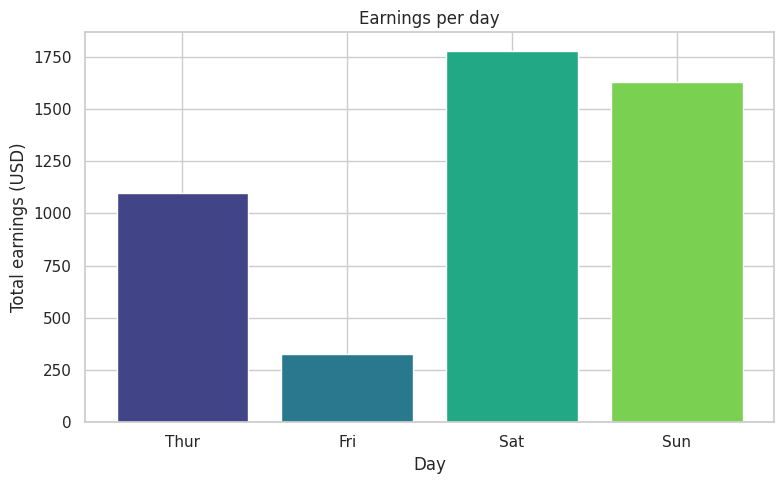

In [41]:
order = ["Thur", "Fri", "Sat", "Sun"]
df["day"] = pd.Categorical(df["day"], categories=order, ordered=True)

# aggregate: sum total_bill by day and keep current pandas behavior explicitly
day_sum = df.groupby("day", observed=False)["total_bill"].sum().reindex(order)

# draw bars with matplotlib using a seaborn palette (avoid seaborn palette-without-hue warning)
colors = sns.color_palette("viridis", n_colors=len(day_sum))

plt.figure(figsize=(8,5))
plt.bar(day_sum.index, day_sum.values, color=colors)
plt.xlabel("Day")
plt.ylabel("Total earnings (USD)")
plt.title("Earnings per day")
plt.tight_layout()
plt.show()


### 4.2 Distribution of Total Bill

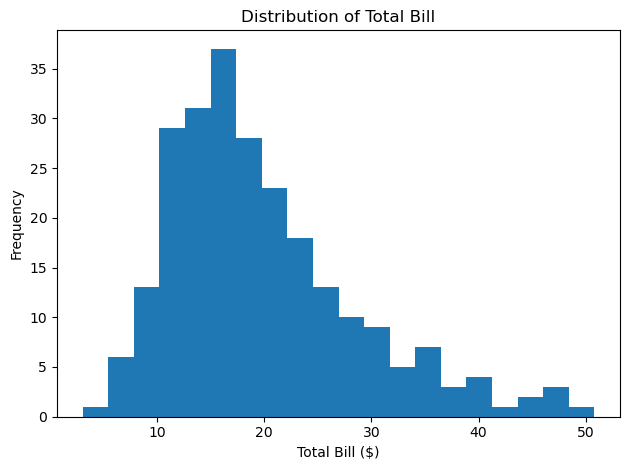

In [ ]:
plt.figure()
plt.hist(df["total_bill"], bins=20)
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/01_total_bill_hist.png", dpi=150)
plt.show()


**Insight:** Most total bills cluster in the lower-to-mid range, with fewer high-bill transactions (a right-skewed pattern is common in spending data).


### 4.3 Amount of party sizes per day

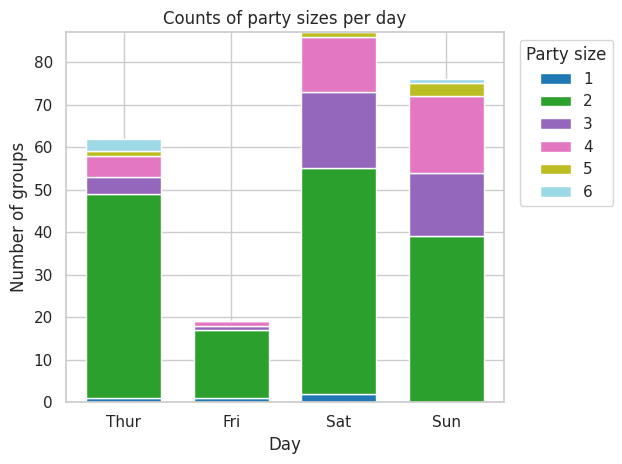

In [56]:
day_order = ["Thur", "Fri", "Sat", "Sun"]
df["day"] = pd.Categorical(df["day"], categories=day_order, ordered=True)
counts = df.groupby(["day", "size"], observed=False).size().unstack(fill_value=0).reindex(day_order)

bottom = np.zeros(len(counts))
colors = plt.cm.tab20(np.linspace(0, 1, counts.shape[1]))

for i, col in enumerate(counts.columns):
    plt.bar(counts.index, counts[col].values, bottom=bottom, color=colors[i], width=0.7, label=str(col))
    bottom += counts[col].values

plt.xlabel("Day")
plt.ylabel("Number of groups")
plt.title("Counts of party sizes per day")
plt.legend(title="Party size", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.4 Distribution of Tip Amount

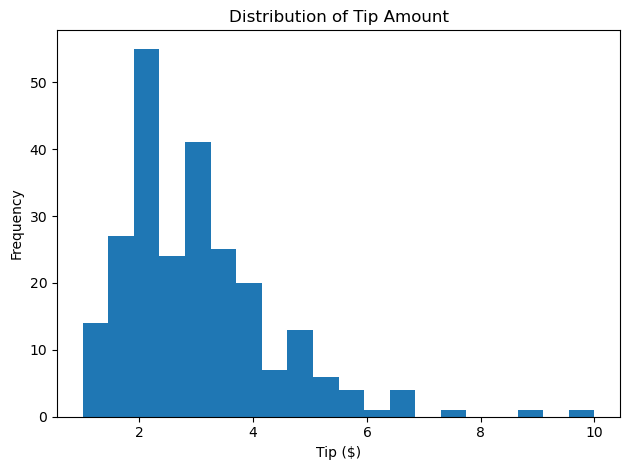

In [ ]:
plt.figure()
plt.hist(df["tip"], bins=20)
plt.title("Distribution of Tip Amount")
plt.xlabel("Tip ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/02_tip_hist.png", dpi=150)
plt.show()


**Insight:** Tips are typically small-to-moderate amounts, with a few larger tips.


### 4.5 Relationship: Total Bill vs Tip

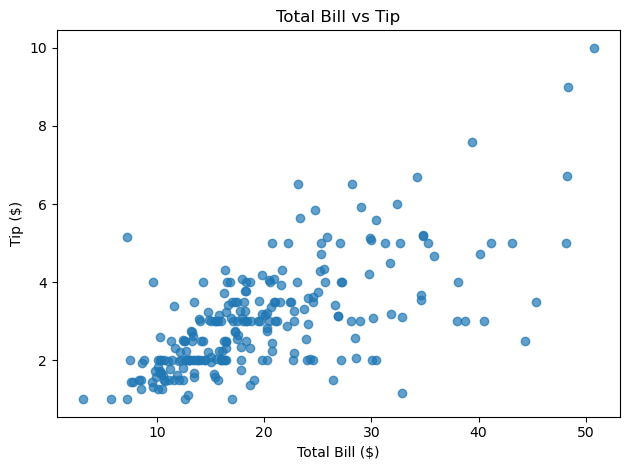

In [ ]:
plt.figure()
plt.scatter(df["total_bill"], df["tip"], alpha=0.7)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.savefig("images/03_bill_vs_tip_scatter.png", dpi=150)
plt.show()


**Insight:** There is a clear positive relationship: higher bills tend to be associated with higher tips.


### 4.6 Tip Percentage by Day (Boxplot)

C:\Users\Aaron\AppData\Local\Temp\ipykernel_20220\2032766289.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_day, labels=days_order, showfliers=True)


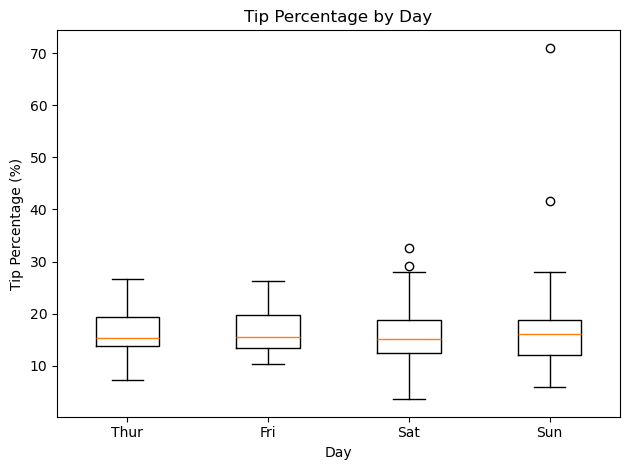

In [ ]:
days_order = ["Thur", "Fri", "Sat", "Sun"]
data_by_day = [df.loc[df["day"] == d, "tip_pct"] for d in days_order]

plt.figure()
plt.boxplot(data_by_day, labels=days_order, showfliers=True)
plt.title("Tip Percentage by Day")
plt.xlabel("Day")
plt.ylabel("Tip Percentage (%)")
plt.tight_layout()
plt.savefig("images/04_tip_pct_by_day_box.png", dpi=150)
plt.show()


**Insight:** Comparing tip percentage by day can reveal whether tipping behavior changes depending on the day of the week.


### 4.7 Average Bill per Person by Time (Lunch vs Dinner)

C:\Users\Aaron\AppData\Local\Temp\ipykernel_20220\1988193655.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group2 = df.groupby("time")["bill_per_person"].mean().reindex(["Lunch", "Dinner"])


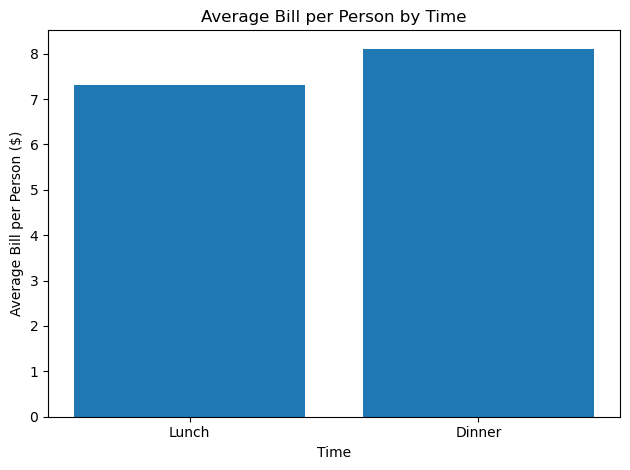

time
Lunch     7.315375
Dinner    8.109560
Name: bill_per_person, dtype: float64

In [ ]:
group2 = df.groupby("time")["bill_per_person"].mean().reindex(["Lunch", "Dinner"])

plt.figure()
plt.bar(group2.index.astype(str), group2.values)
plt.title("Average Bill per Person by Time")
plt.xlabel("Time")
plt.ylabel("Average Bill per Person ($)")
plt.tight_layout()
plt.savefig("images/06_bill_per_person_by_time_bar.png", dpi=150)
plt.show()

group2


**Insight:** Dinner may show higher spending per person than lunch, depending on the dataset distribution.


### 4.8 Correlation (Numerical Variables)

In [ ]:
corr = df[["total_bill", "tip", "size", "tip_pct", "bill_per_person"]].corr(numeric_only=True)
corr


,total_bill,tip,size,tip_pct,bill_per_person
total_bill,1.000000,0.675734,0.598315,-0.338624,0.647497
tip,0.675734,1.000000,0.489299,0.342370,0.347393
size,0.598315,0.489299,1.000000,-0.142860,-0.175412
tip_pct,-0.338624,0.342370,-0.142860,1.000000,-0.314156
bill_per_person,0.647497,0.347393,-0.175412,-0.314156,1.000000


**Insight:** Correlation quantifies linear relationships. We typically expect `total_bill` and `tip` to correlate positively.


## 5) Key Findings & Conclusions
Below is a concise summary of the main insights from the analysis.

**Findings:**
1. The dataset has **no missing values**, so we can proceed directly to analysis.
2. **Total bill and tip** show a positive relationship: higher bills generally lead to higher tips.
3. Tip behavior can be analyzed more fairly using **tip percentage (`tip_pct`)** instead of tip amount alone.
4. Differences in **tip percentage** across categories (day, smoker, time) can reveal behavioral patterns.

**Conclusion:** The `tips` dataset provides a clear, clean example of transactional data suitable for exploring how context (time, day, smoker status, and party size) may relate to tipping behavior.
